<a href="https://colab.research.google.com/github/CPTR295/ML1/blob/main/Computer_Vision_Using_Convolutional_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import sklearn
import numpy as np
import os
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules
import tensorflow as tf
from tensorflow import keras
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
def plot_image(image):
  plt.imshow(image, cmap="gray", interpolation="nearest")
  plt.axis("off")

def plot_color_image(image):
  plt.imshow(image, interpolation="nearest")
  plt.axis("off")



### Convolution

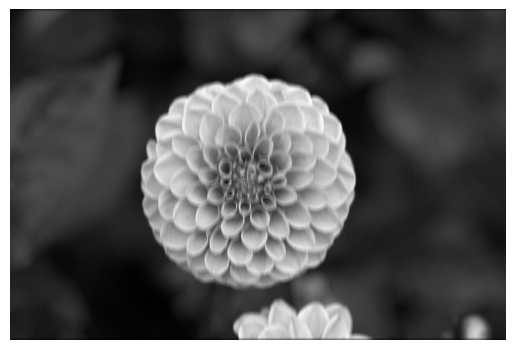

In [4]:
from sklearn.datasets import load_sample_image
china = load_sample_image("china.jpg")/255
flower = load_sample_image("flower.jpg")/255
images = np.array([china, flower])
batch_size,height,width,channels = images.shape

filters = np.zeros(shape=(7,7,channels,2),dtype=np.float32)
filters[:,3,:,0]=1
filters[3,:,:,1]=1
outputs = tf.nn.conv2d(images,filters,strides=1,padding="SAME")
plt.imshow(outputs[1,:,:,0],cmap="gray")
plt.axis("off")
plt.show()

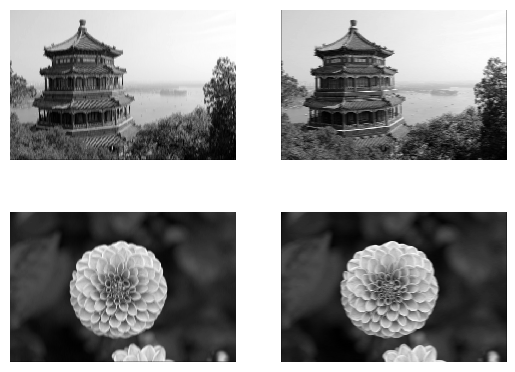

In [5]:
for image_index in (0,1):
  for feature_index in (0,1):
    plt.subplot(2,2,image_index*2+feature_index+1)
    plot_image(outputs[image_index,:,:,feature_index])
plt.show()

In [6]:
def crop(image):
  return image[150:220,130:250]

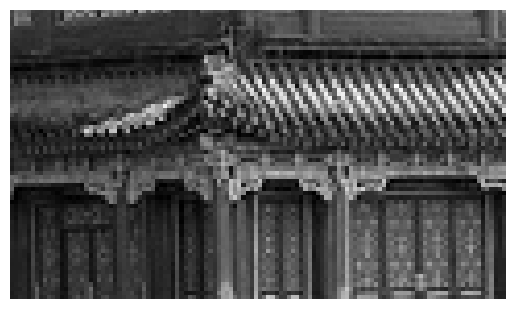

                            Original Image
  china_vertical                              china_horizontal


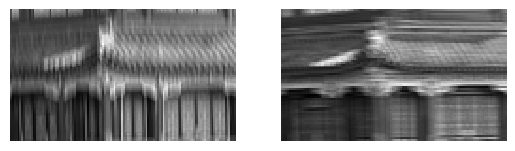

In [7]:
plot_image(crop(images[0,:,:,0]))
plt.show()
print('                            Original Image')

for feature_map_index,filename in enumerate(["china_vertical", "china_horizontal"]):
  plt.subplot(1,2,feature_map_index+1)
  plot_image(crop(outputs[0,:,:,feature_map_index]))
print("  china_vertical", "                             china_horizontal")

In [8]:
conv = keras.layers.Conv2D(filters=2,kernel_size=7,strides=1,padding="SAME",activation="relu",input_shape=outputs.shape)
conv_outputs = conv(images)
conv_outputs.shape #The output is a 4D tensor. The dimensions are: batch size, height, width, channels.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


TensorShape([2, 427, 640, 2])

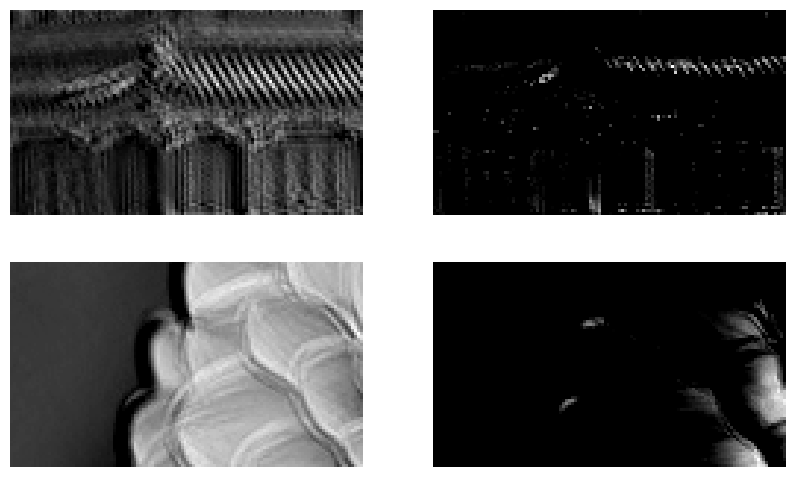

In [9]:
plt.figure(figsize=(10,6))
for image_index in (0,1):
  for feature_index in (0,1):
    plt.subplot(2,2,image_index*2+feature_index+1)
    plot_image(crop(conv_outputs[image_index,:,:,feature_index]))
plt.show()#Since the filters are initialized randomly, they'll initially detect random patterns.

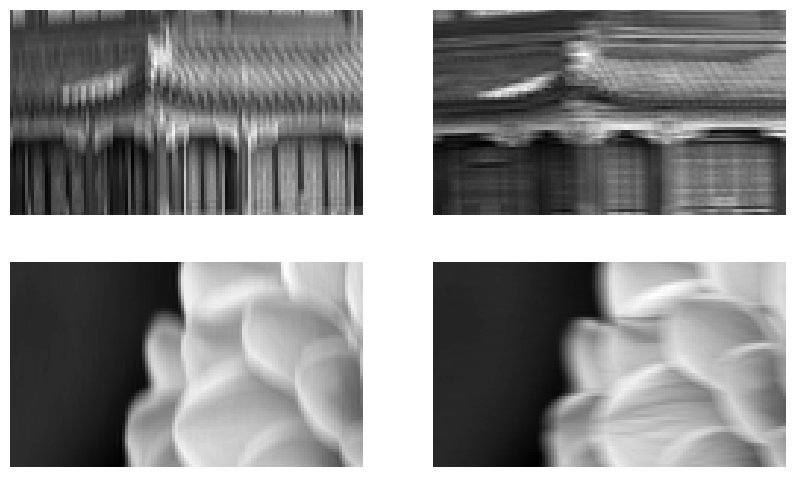

In [10]:
#If we want, we can set the filters to be the ones we manually defined/set biases to zero [Usually not needed]
conv.set_weights([filters,np.zeros(2)])
conv_outputs = conv(images)
plt.figure(figsize=(10,6))
for image_index in (0,1):
  for feature_index in (0,1):
    plt.subplot(2,2,image_index*2+feature_index+1)
    plot_image(crop(conv_outputs[image_index,:,:,feature_index]))
plt.show()

## Pooling Layers

### Max Pooling

In [11]:
max_pool = keras.layers.MaxPool2D(pool_size=2)
cropped_images = np.array([crop(image) for image in images],dtype=np.float32)
output = max_pool(cropped_images)
output.shape


TensorShape([2, 35, 60, 3])

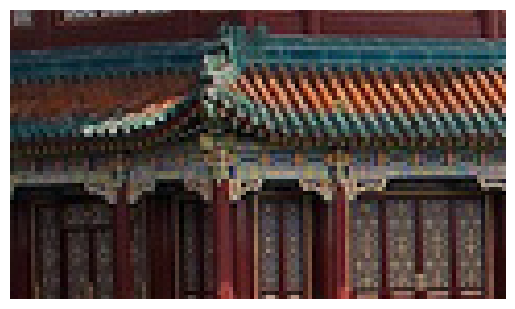

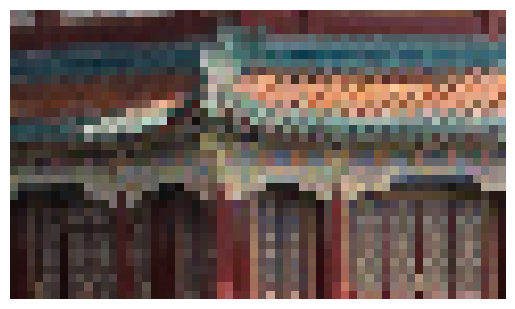

In [12]:
plot_image(cropped_images[0])
plt.show()
plot_image(output[0])
plt.show()

### Average Pooling

In [13]:
avg_pool = keras.layers.AvgPool2D(pool_size=2)
output = avg_pool(cropped_images)
output.shape

TensorShape([2, 35, 60, 3])

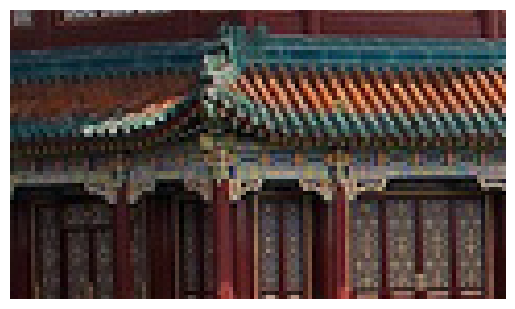

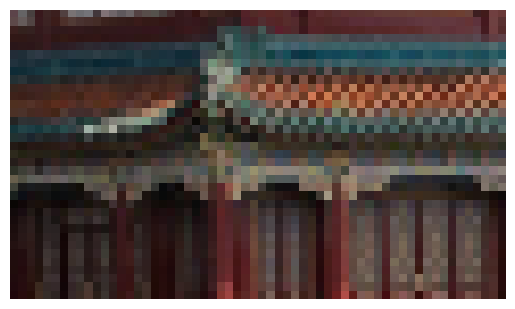

In [14]:
plot_image(cropped_images[0])
plt.show()
plot_image(output[0])
plt.show()

# Tackling Fashion MNIST With a CNN

In [15]:
(X_train_full,y_train_full),(X_test,y_test) = keras.datasets.fashion_mnist.load_data()

In [16]:
X_train,X_valid = X_train_full[:-5000],X_train_full[-5000:]
y_train,y_valid = y_train_full[:-5000],y_train_full[-5000:]

X_mean = X_train.mean(axis=0,keepdims=True)
X_std = X_train.std(axis=0,keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[...,np.newaxis]
X_valid = X_valid[...,np.newaxis]
X_test = X_test[...,np.newaxis]

In [17]:
from functools import partial
DefaultConv2D = partial(keras.layers.Conv2D,kernel_size=3,padding="SAME",activation='relu')

In [18]:
model = keras.models.Sequential([
    DefaultConv2D(filters=64,kernel_size=7,input_shape=[28,28,1]),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10,activation='softmax')
])

In [19]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='nadam',metrics=['accuracy'])
his = model.fit(X_train,y_train,epochs=10,validation_data=(X_valid,y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - accuracy: 0.7557 - loss: 0.7151 - val_accuracy: 0.8630 - val_loss: 0.3963
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8559 - loss: 0.4322 - val_accuracy: 0.8720 - val_loss: 0.3508
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8743 - loss: 0.3729 - val_accuracy: 0.8828 - val_loss: 0.3186
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8843 - loss: 0.3411 - val_accuracy: 0.8982 - val_loss: 0.2921
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8923 - loss: 0.3169 - val_accuracy: 0.8926 - val_loss: 0.3091
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8965 - loss: 0.3063 - val_accuracy: 0.8876 - val_loss: 0.3108
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9054 - loss: 0.2810 - val_accuracy: 0.8816 - val_loss: 0.3283
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9080 - loss: 

In [20]:
score = model.evaluate(X_test,y_test)
score

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8930 - loss: 0.3231


[0.32314592599868774, 0.8930000066757202]

In [21]:
X_new = X_test[:10]
y_pred = model.predict(X_new)
#Compare Results
print("Predicted classes:", np.argmax(y_pred,axis=1))
print("Actual classes:   ", y_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step
Predicted classes: [9 2 1 1 6 1 4 6 5 7]
Actual classes:    [9 2 1 1 6 1 4 6 5 7]


## ResNet-34


### Preprocessing Fashion MNIST for ResNet

In [ ]:
import tensorflow as tf

def preprocess_for_resnet(images):
    """Preprocess grayscale images for ResNet50."""

    # Cast to float32 (important for resize)
    images = tf.cast(images, tf.float32)

    # Resize to 224x224
    images_resized = tf.image.resize(images, [224, 224], method='bilinear')

    # Convert grayscale to RGB (replicates the channel)
    images_rgb = tf.image.grayscale_to_rgb(images_resized)

    return images_rgb


# Apply preprocessing
X_train_resnet = preprocess_for_resnet(X_train)
X_valid_resnet = preprocess_for_resnet(X_valid)
X_test_resnet  = preprocess_for_resnet(X_test)

print(f"X_train_resnet shape: {X_train_resnet.shape}")
print(f"X_valid_resnet shape: {X_valid_resnet.shape}")
print(f"X_test_resnet shape: {X_test_resnet.shape}")

In [ ]:
DefaultConv2D = partial(keras.layers.Conv2D,kernel_size=3,strides=1,padding='SAME',use_bias=False)

class ResidualUnit(keras.layers.Layer):
  def __init__(self,filters,strides=1,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.activation = keras.activations.get(activation)
    self.main_layers = [
        DefaultConv2D(filters,strides=strides),
        keras.layers.BatchNormalization(),
        self.activation,
        DefaultConv2D(filters),
        keras.layers.BatchNormalization()
    ]
    self.skip_layers = []
    if strides > 1:
        self.skip_layers = [
            DefaultConv2D(filters,kernel_size=1,strides=strides),
            keras.layers.BatchNormalization()
        ]
  def call(self,inputs):
    Z = inputs
    for layer in self.main_layers:
      Z = layer(Z)
    skip_Z = inputs
    for layer in self.skip_layers:
      skip_Z = layer(skip_Z)
    return self.activation(Z+skip_Z)

In [ ]:
model = keras.models.Sequential()
model.add(DefaultConv2D(64,kernel_size=7,strides=2,input_shape=[224,224,3]))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPool2D(pool_size=3,strides=2,padding='same'))
prev_filters = 64
for filters in [64]*3+[128]*4+[256]*6+[512]*3:
  strides = 1 if filters == prev_filters else 2
  model.add(ResidualUnit(filters,strides=strides))
  prev_filters = filters
model.add(keras.layers.GlobalAvgPool2D())
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(10,activation='softmax'))

In [ ]:
model.summary()

### Retraining ResNet-34 with preprocessed data

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='nadam',metrics=['accuracy'])
his = model.fit(X_train_resnet, y_train, epochs=3, validation_data=(X_valid_resnet, y_valid))